# **Project 2: Exploratory Data Analysis**
# **Intern:** Aiman Sarfraz
# **Domain:** Data Analytics

**Step 1: Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Step 2: Loading Dataset**

In [2]:
from google.colab import files
uploade=files.upload()

Saving Cleaned_Ecommerce_Dataset.xlsx to Cleaned_Ecommerce_Dataset.xlsx


**Step 3: Display dataset**

In [4]:
df=pd.read_excel('Cleaned_Ecommerce_Dataset.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


**Step 4: understanding data**

In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Dataset Information")
print("-"*50)
df.info()

Rows: 1200
Columns: 14
Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13 

**Step 4: Descriptive Statistics**

In [11]:
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [12]:
print("Average Quantity:",
      df["Quantity"].mean())

print("Median Quantity:",
      df["Quantity"].median())

print("Average Total Price:",
      df["TotalPrice"].mean())

print("Median Total Price:",
      df["TotalPrice"].median())

Average Quantity: 2.9458333333333333
Median Quantity: 3.0
Average Total Price: 1053.9683
Median Total Price: 823.615


**Step 5: Top Selling Products**

In [14]:
top_products = (
    df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)
)
print(top_products.head(10))

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64


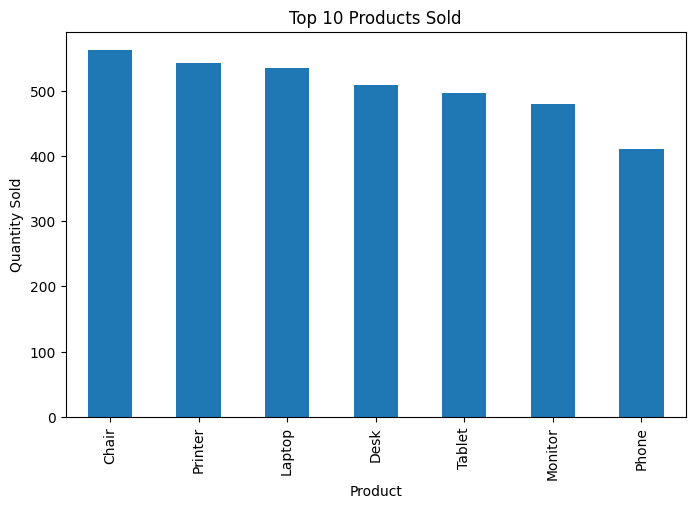

In [15]:
top_products.head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 Products Sold")
plt.ylabel("Quantity Sold")
plt.show()

**Step 6: Product Revenue**

In [16]:
revenue = (
    df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
)
print(revenue.head(10))

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


**Step 7: Payment Method Analysis**

In [17]:
payment = (
    df["PaymentMethod"].value_counts()
)
print(payment)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


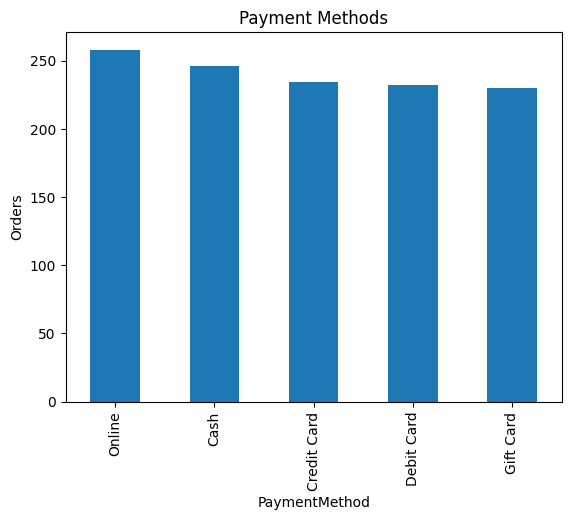

In [18]:
payment.plot(kind="bar")

plt.title("Payment Methods")
plt.ylabel("Orders")
plt.show()

**Step 8: Order Status Analysis**

In [19]:
status = (
    df["OrderStatus"].value_counts()
)
print(status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


**Step 9: Referral Source Analysis**

In [20]:
referral = (
    df["ReferralSource"].value_counts()
)
print(referral)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


**Step 10: Monthly Sales Trend**

In [21]:
# Converting Data Columns into months
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

In [22]:
# monthly revenue
monthly_sales = (
    df.groupby("Month")["TotalPrice"].sum()
)
print(monthly_sales)

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


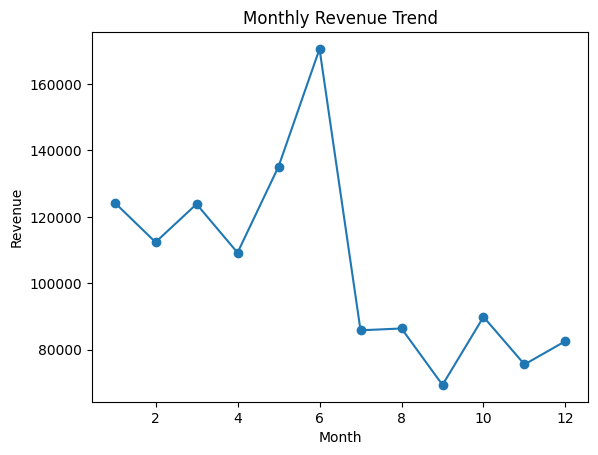

In [23]:
monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

**Step 11: Outlier Detection**

In [24]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower)
    |
    (df["TotalPrice"] > upper)
]

print("Number of Outliers:",
      len(outliers))

Number of Outliers: 8


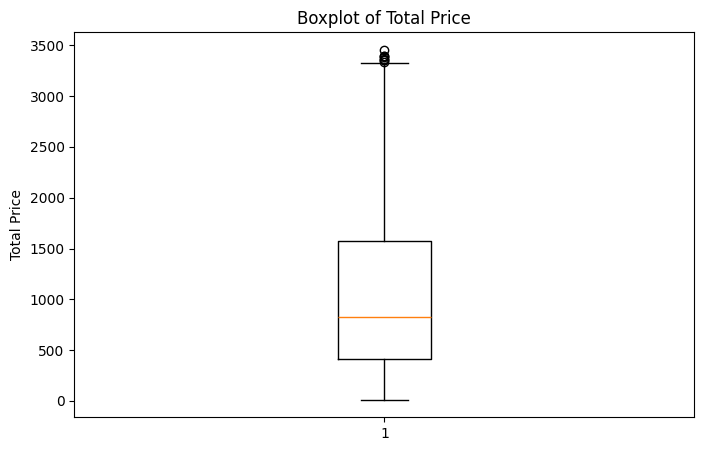

In [25]:
plt.figure(figsize=(8,5))
plt.boxplot(df["TotalPrice"])
plt.title("Boxplot of Total Price")
plt.ylabel("Total Price")
plt.show()

**Step 12: Correlation Analysis**

In [26]:
print(
    df[
        ["Quantity",
         "UnitPrice",
         "ItemsInCart",
         "TotalPrice"]
    ].corr()
)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000
